# 5.4.2 不变分布与长期收敛的条件

## 学习目标与先修知识

能求两态不变分布（invariant distribution），区分存在、唯一与逐时刻收敛；用周期链和多吸收态（absorbing state）解释不可约（irreducible）、非周期（aperiodic）等条件。

先修：上一节的转移矩阵（transition matrix）和分布（distribution）传播；固定点（fixed point）、几何倍数与线性方程。 [复习上一节](01-状态路径与概率分布的两种推进.ipynb)。

## 具体问题

解出 πP=π，就能断定任意起点最终接近 π 吗？一条每步必定翻转的链给出非常短的反例。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
flip=np.array([[0.,1.],[1.,0.]])
p=np.array([1.,0.])
print('交替链前三步：',p.tolist(),(p@flip).tolist(),(p@flip@flip).tolist())
print('均匀分布一步后：',(np.array([.5,.5])@flip).tolist())

交替链前三步： [1.0, 0.0] [0.0, 1.0] [1.0, 0.0]
均匀分布一步后： [0.5, 0.5]


## 模型假设

有限状态（state）、时间齐次（time-homogeneous）。两态矩阵（matrix）为 [[1−α,α],[β,1−β]]，0≤α,β≤1。比较普通切换 (0.2,0.1)、周期切换 (1,1) 与两个吸收态 (0,0)。吸收态一旦进入便不会离开；这些例子都按精确分布递推，不依赖模拟路径去推断定理。

## 数学解释与推导

不变分布 π 满足 πP=π、πᵢ≥0、Σπᵢ=1。在两态模型（model）中，流向两边的概率质量（probability mass）平衡（equilibrium）：π0α=π1β。若 α+β>0，唯一解为
$$\pi=\left(\frac{\beta}{\alpha+\beta},\frac{\alpha}{\alpha+\beta}\right).$$
α=β=0 时 P 为单位矩阵（identity matrix），每个初始分布都不变，因此不能给出唯一 π。

令 z[n]=P(X[n]=1)。由行传播可得 z[n+1]=α+(1−α−β)z[n]。相减得
$$z_n-\pi_1=(1-\alpha-\beta)^n(z_0-\pi_1).$$
所以只要 0<α+β<2 就收敛；α+β=2 必为 α=β=1，倍数 −1 使一般起点交替，只有不变初值（initial condition）保持不变。这里再次需要绝对值小于 1，不能只说倍数小于 1。

有限链总有至少一个不变分布。不可约指任意状态之间经过有限步可以互达；非周期指返回一个状态的可能步数的最大公约数为 1。有限、不可约且非周期是唯一不变分布并从任意初始分布收敛的一组充分条件。它们不是所有可约链收敛的必要条件，例如唯一吸收类也可能吸引所有起点。完整一般定理证明见拓展；本节两态结论由上式直接证明。

周期链的逐时刻分布可能不收敛，但把前 N 个分布取时间平均可趋于不变分布。时间平均与固定时刻群体分布是不同对象，不能用其中一个替另一个作结论。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def stationary_two(alpha, beta):
    if alpha+beta == 0:
        return None
    return [beta/(alpha+beta), alpha/(alpha+beta)]


def propagate(matrix, initial, steps):
    values = [list(initial)]
    for _ in range(steps):
        current = values[-1]
        values.append([sum(current[i]*matrix[i][j] for i in range(len(current))) for j in range(len(current))])
    return values

## 对照实验

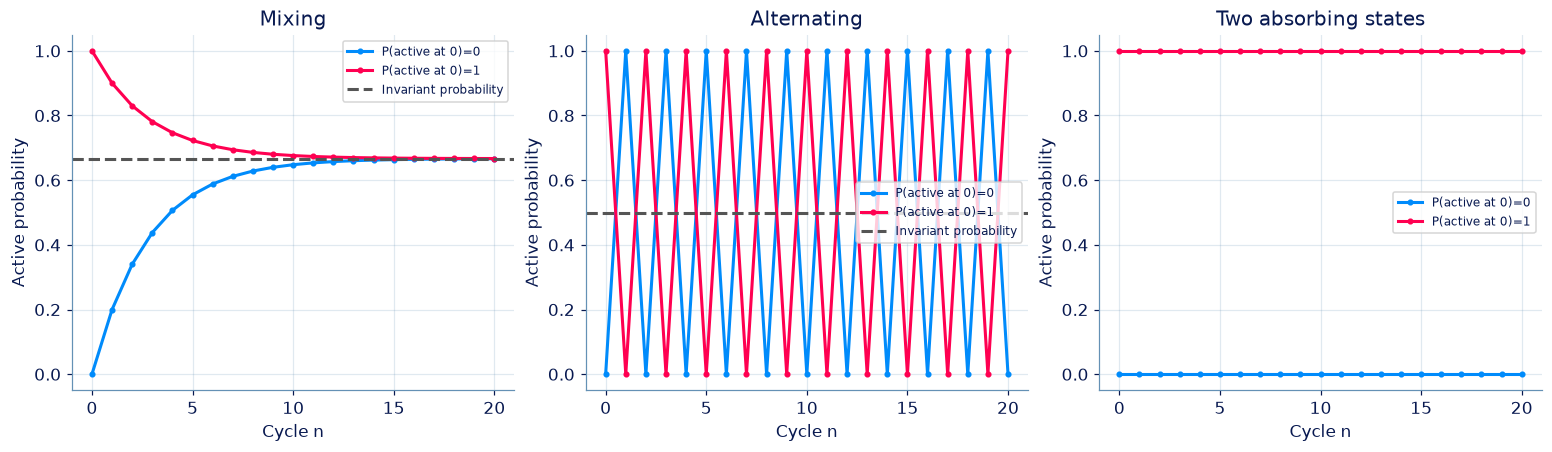

三种案例的不变分布结果（None 表示不唯一）： [[0.3333333333333333, 0.6666666666666666], [0.5, 0.5], None]


In [4]:
cases=[('Mixing',.2,.1),('Alternating',1.,1.),('Two absorbing states',0.,0.)]
fig,axes=plt.subplots(1,3,figsize=(14,4));n=np.arange(21)
for ax,(name,alpha,beta) in zip(axes,cases):
    matrix=[[1-alpha,alpha],[beta,1-beta]]
    for initial,color in [([1,0],BLUE),([0,1],PINK)]:
        values=np.array(propagate(matrix,initial,20))
        ax.plot(n,values[:,1],'o-',ms=3,color=color,label=f'P(active at 0)={initial[1]}')
    pi=stationary_two(alpha,beta)
    if pi is not None:ax.axhline(pi[1],color=GRAY,ls='--',label='Invariant probability')
    ax.set(xlabel='Cycle n',ylabel='Active probability',ylim=(-.05,1.05),title=name);ax.legend(fontsize=8)
plt.show()
print('三种案例的不变分布结果（None 表示不唯一）：',[stationary_two(a,b) for _,a,b in cases])

## 结果解释

普通链的不同起点接近同一分布；交替链有唯一不变分布，却持续往返；单位矩阵保留所有初始信息。图形支持例子的行为，真正的收敛条件来自偏差递推和结构条件。

### 独立核对

用矩阵不变方程检查闭式；交替链的有限偶数样本平均精确为 1/2，但相邻末态依然不同。

In [5]:
for alpha,beta in [(0,.3),(.2,.1),(1,1)]:
    matrix=np.array([[1-alpha,alpha],[beta,1-beta]])
    pi=np.array(stationary_two(alpha,beta))
    np.testing.assert_allclose(pi@matrix,pi)
assert stationary_two(0,0) is None
alternating=np.array(propagate([[0,1],[1,0]],[1,0],99))
np.testing.assert_allclose(alternating.mean(axis=0),[.5,.5])
assert not np.allclose(alternating[-1],alternating[-2])
print('边界、不变方程、时间平均与逐时刻不收敛的反例一致。')

边界、不变方程、时间平均与逐时刻不收敛的反例一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-04-随机过程与马尔可夫模型/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：解两态不变分布并保留退化情形

转移矩阵（transition matrix）为 [[1−alpha,alpha],[beta,1−beta]]。返回唯一不变分布（invariant distribution）；若所有分布（distribution）都不变则返回 None。不在本题判断是否从任意初始分布收敛。

**函数与代码模板**

```python
def solve(
    alpha: float,
    beta: float,
) -> list[float] | None:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `alpha` | `float` | 状态（state） 0 转到 1 的概率（probability）。 | 1 |
| `beta` | `float` | 状态 1 转到 0 的概率。 | 1 |

**返回值**

直接返回 stationary（list[float] | None）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `stationary` | <code>list[float] &#124; None</code> | 状态 0、1 的不变概率；不唯一时为 None。 | 1 |

**计算规则**

alpha+beta>0 时返回 [beta/(alpha+beta),alpha/(alpha+beta)]；两者都为 0 时返回 None。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 0≤alpha,beta≤1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| alpha | 状态（state） 0 转到 1 的概率（probability）。 | 0.2 | 1 |
| beta | 状态 1 转到 0 的概率。 | 0.1 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
alpha = 0.2
beta = 0.1

result = solve(alpha, beta)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| stationary | 状态 0、1 的不变概率；不唯一时为 None。 | [0.3333333333333333, 0.6666666666666666] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.3333333333333333, 0.6666666666666666]
```

**样例解释**

流量（flow）平衡（equilibrium） π0*0.2=π1*0.1 加上和为 1，得 [1/3,2/3]。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：解两态不变分布并保留退化情形](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-stationary)

### 第 2 题 · 多项选择题：有不变分布为何仍不收敛

P=[[0,1],[1,0]]，从 [1,0] 出发。哪些成立？

- **A.** [0.5,0.5] 是不变分布（invariant distribution）。
- **B.** 任意初始分布（distribution）都逐时刻收敛到 [0.5,0.5]。
- **C.** 从 [0.5,0.5] 出发可始终保持不变。
- **D.** 分布在 [1,0] 与 [0,1] 之间交替。

[作答：有不变分布为何仍不收敛](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-periodic)

### 第 3 题 · 单项选择题：哪组条件足以保证有限链收敛

对有限状态（state）、时间齐次（time-homogeneous）链，以下哪组条件保证唯一不变分布（invariant distribution）且从任意初始分布（distribution）收敛到它？

- **A.** 不可约（irreducible）且非周期（aperiodic）。
- **B.** 只有样本曲线看起来平稳。
- **C.** 只要求元素非负。
- **D.** 只要求存在一个不变分布。

[作答：哪组条件足以保证有限链收敛](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-ergodic-conditions)

### 第 4 题 · 单项选择题：两个吸收态保留多少初始信息

P 为二阶单位矩阵（identity matrix）。哪项正确？

- **A.** 多模拟几步便会混合。
- **B.** 所有初始分布（distribution）都收敛到 [0.5,0.5]。
- **C.** 每个初始分布都保持原样，不变分布（invariant distribution）不唯一。
- **D.** 该链没有不变分布。

[作答：两个吸收态保留多少初始信息](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-absorbing)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 16—18 讲：分类、不变分布与长期行为。